In [171]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [172]:
df = pd.read_csv("round1.csv")
df.head()

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,cuisines_count,listed_in(type),listed_in(city)
0,"Address_874, Bangalore",KFC,No,Yes,3.8/5,2005,080-1914394,Indiranagar,Bakery,Biryani,"Mexican, Thai, Chinese, Desserts",600,Sample Review Text...,4,Delivery,Bengaluru
1,"Address_511, Bangalore",Resto_511,No,No,3.4/5,1731,080-2396415,MG Road,Bar,Dosa,"Desserts, North Indian",1500,Sample Review Text...,2,Buffet,Bengaluru
2,"Address_656, Bangalore",Empire Restaurant,Yes,No,4.7/5,1177,080-4996784,NaN,Bakery,Pasta,"Fast Food, Beverages, Continental, Chinese, It...",2000,Sample Review Text...,5,Delivery,Bengaluru
3,"Address_96, Bangalore",Pizza Hut,Yes,Yes,3.2/5,2101,080-4959345,Jayanagar,Casual Dining,Sushi,"Fast Food, Desserts",200,Sample Review Text...,2,Drinks & nightlife,Bengaluru
4,"Address_759, Bangalore",Resto_759,Yes,Yes,4.7/5,665,080-5449004,Koramangala,Bakery,Sushi,"Continental, Mexican","1,200",Sample Review Text...,2,Delivery,Bengaluru


In [173]:
df.shape

(1050, 16)

In [174]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   address                      1050 non-null   str  
 1   name                         1050 non-null   str  
 2   online_order                 1050 non-null   str  
 3   book_table                   1050 non-null   str  
 4   rate                         995 non-null    str  
 5   votes                        1050 non-null   int64
 6   phone                        1050 non-null   str  
 7   location                     1030 non-null   str  
 8   rest_type                    1050 non-null   str  
 9   dish_liked                   1050 non-null   str  
 10  cuisines                     1050 non-null   str  
 11  approx_cost(for two people)  1035 non-null   str  
 12  reviews_list                 1050 non-null   str  
 13  cuisines_count               1050 non-null   int64
 14  lis

In [175]:
df.isnull().sum()

address                         0
name                            0
online_order                    0
book_table                      0
rate                           55
votes                           0
phone                           0
location                       20
rest_type                       0
dish_liked                      0
cuisines                        0
approx_cost(for two people)    15
reviews_list                    0
cuisines_count                  0
listed_in(type)                 0
listed_in(city)                 0
dtype: int64

In [176]:
df['dish_liked'].head()

0    Biryani
1       Dosa
2      Pasta
3      Sushi
4      Sushi
Name: dish_liked, dtype: str

In [177]:
df['dish_liked'].nunique()

8

In [178]:
df.drop(columns=['address', 'phone', 'reviews_list'], inplace=True)

In [179]:
df.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes', 'location',
       'rest_type', 'dish_liked', 'cuisines', 'approx_cost(for two people)',
       'cuisines_count', 'listed_in(type)', 'listed_in(city)'],
      dtype='str')

In [180]:
df.rename(columns={
    'approx_cost(for two people)': 'cost_for_two',
    'listed_in(type)': 'service_type',
    'listed_in(city)': 'city'
}, inplace=True)

In [181]:
df.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes', 'location',
       'rest_type', 'dish_liked', 'cuisines', 'cost_for_two', 'cuisines_count',
       'service_type', 'city'],
      dtype='str')

In [182]:
df['rate'].unique()

<StringArray>
['3.8/5', '3.4/5', '4.7/5', '3.2/5', '2.8/5', '2.4/5',   'NEW',     nan,
 '4.3/5', '2.2/5', '4.1/5', '3.3/5', '4.2/5', '3.0/5', '2.9/5', '4.5/5',
 '2.1/5', '3.7/5', '3.5/5', '2.0/5', '2.3/5', '3.6/5', '3.9/5', '4.6/5',
     '-', '2.7/5', '3.1/5', '4.8/5', '4.4/5', '4.0/5', '2.5/5', '4.9/5',
 '2.6/5']
Length: 33, dtype: str

In [183]:
df['rate'] = df['rate'].replace(['NEW', '-'], np.nan)

In [184]:
df['rate'].unique()

<StringArray>
['3.8/5', '3.4/5', '4.7/5', '3.2/5', '2.8/5', '2.4/5',     nan, '4.3/5',
 '2.2/5', '4.1/5', '3.3/5', '4.2/5', '3.0/5', '2.9/5', '4.5/5', '2.1/5',
 '3.7/5', '3.5/5', '2.0/5', '2.3/5', '3.6/5', '3.9/5', '4.6/5', '2.7/5',
 '3.1/5', '4.8/5', '4.4/5', '4.0/5', '2.5/5', '4.9/5', '2.6/5']
Length: 31, dtype: str

In [185]:
df['rate'] = df['rate'].str.replace('/5', '', regex=False)

In [186]:
df['rate'].head()

0    3.8
1    3.4
2    4.7
3    3.2
4    4.7
Name: rate, dtype: str

In [187]:
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

In [188]:
df['rate'].dtype


dtype('float64')

In [189]:
df['rate'].isnull().sum()

np.int64(137)

In [190]:
df = df.dropna(subset=['rate'])

In [191]:
df.shape

(913, 13)

In [192]:
df['cost_for_two'].unique()

<StringArray>
[  '600',  '1500',  '2000',   '200', '1,200',  '1200',  '3000',  '1000',
 '1,000',  '2500',   '800',   '400',     nan, '2,000', '2,500', '1,500',
 '3,000']
Length: 17, dtype: str

In [193]:
df['cost_for_two'] = df['cost_for_two'].str.replace(',', '', regex=False)

In [194]:
df['cost_for_two'].unique()

<StringArray>
['600', '1500', '2000', '200', '1200', '3000', '1000', '2500', '800', '400',
 nan]
Length: 11, dtype: str

In [195]:
df['cost_for_two'] = pd.to_numeric(df['cost_for_two'], errors='coerce')

In [196]:
df['cost_for_two'].dtype

dtype('float64')

In [197]:
df['cost_for_two'].isnull().sum()

np.int64(11)

In [198]:
df = df.dropna(subset=['cost_for_two'])

In [199]:
df.shape

(902, 13)

In [200]:
df['location'].isnull().sum()

np.int64(18)

In [201]:
df = df.dropna(subset=['location'])

In [202]:
df.shape

(884, 13)

In [203]:
df['online_order'].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

In [204]:
df['book_table'].unique()

<StringArray>
['Yes', 'No']
Length: 2, dtype: str

In [205]:
df['online_order'] = df['online_order'].map({'Yes': 1, 'No': 0})
df['book_table'] = df['book_table'].map({'Yes': 1, 'No': 0})

In [206]:
df[['online_order', 'book_table']].head()


,online_order,book_table
0,0,1
1,0,0
3,1,1
4,1,1
5,0,0


In [207]:
df[['online_order', 'book_table']].dtypes

online_order    int64
book_table      int64
dtype: object

In [208]:
text_cols = ['location', 'rest_type', 'cuisines', 'service_type', 'city', 'dish_liked']

for col in text_cols:
    df[col] = df[col].str.strip().str.lower()

In [209]:
df['location'].unique()[:10]

<StringArray>
[ 'indiranagar',      'mg road',    'jayanagar',  'koramangala',
   'hsr layout',   'whitefield', 'marathahalli',     'jp nagar']
Length: 8, dtype: str

In [210]:
df.duplicated().sum()

np.int64(40)

In [211]:
df = df.drop_duplicates()

In [212]:
df.shape

(844, 13)

In [213]:
df.duplicated().sum()

np.int64(0)

In [214]:
df['name'].value_counts().head(10)

name
Leon Grill           77
McDonald's           71
Nandhana Palace      70
Onesta               69
Pizza Hut            65
Burger King          60
KFC                  57
Empire Restaurant    55
Resto_511             1
Resto_759             1
Name: count, dtype: int64

In [215]:
df[['name','location']].duplicated().sum()

np.int64(460)

In [216]:
df[df[['name','location']].duplicated(keep=False)].head(10)

,name,online_order,book_table,rate,votes,location,rest_type,dish_liked,cuisines,cost_for_two,cuisines_count,service_type,city
0,KFC,0,1,3.8,2005,indiranagar,bakery,biryani,"mexican, thai, chinese, desserts",600.0,4,delivery,bengaluru
3,Pizza Hut,1,1,3.2,2101,jayanagar,casual dining,sushi,"fast food, desserts",200.0,2,drinks & nightlife,bengaluru
6,Pizza Hut,0,0,3.2,164,hsr layout,bar,pasta,"chinese, mexican, beverages, desserts, south i...",3000.0,5,buffet,bengaluru
11,Burger King,1,0,4.3,1871,whitefield,casual dining,sushi,"italian, continental",1000.0,2,cafes,bengaluru
12,Burger King,0,1,3.2,1768,koramangala,bar,pasta,"mexican, north indian, italian",1200.0,3,cafes,bengaluru
13,Nandhana Palace,0,0,2.2,1850,hsr layout,fine dining,salad,"chinese, mexican, desserts",2500.0,3,pubs and bars,bengaluru
17,KFC,0,1,3.8,2776,jayanagar,fine dining,sushi,north indian,1000.0,1,pubs and bars,bengaluru
18,Burger King,0,1,3.0,2199,indiranagar,casual dining,sushi,"thai, south indian",3000.0,2,cafes,bengaluru
19,KFC,1,0,2.2,980,marathahalli,bakery,biryani,italian,2000.0,1,drinks & nightlife,bengaluru
22,KFC,1,0,3.0,968,jayanagar,casual dining,pasta,"fast food, thai, italian, chinese, desserts",800.0,5,delivery,bengaluru


In [217]:
df['rate'].describe()

count    844.000000
mean       3.490995
std        0.836753
min        2.000000
25%        2.800000
50%        3.500000
75%        4.200000
max        4.900000
Name: rate, dtype: float64

In [218]:
df['cost_for_two'].describe()

count     844.000000
mean     1331.516588
std       902.902699
min       200.000000
25%       600.000000
50%      1000.000000
75%      2000.000000
max      3000.000000
Name: cost_for_two, dtype: float64

In [219]:
df['high_rated'] = (df['rate'] >= 4.0).astype(int)

In [220]:
df['high_rated'].value_counts()

high_rated
0    549
1    295
Name: count, dtype: int64

In [221]:
def price_category(x):
    if x <= 800:
        return 'budget'
    elif x <= 2000:
        return 'mid_range'
    else:
        return 'premium'

df['price_category'] = df['cost_for_two'].apply(price_category)

In [222]:
df['price_category'].value_counts()

price_category
budget       345
mid_range    317
premium      182
Name: count, dtype: int64

In [223]:
df['votes'].describe()

count     844.000000
mean     1444.289100
std       844.564519
min         6.000000
25%       695.750000
50%      1432.000000
75%      2117.000000
max      2995.000000
Name: votes, dtype: float64

In [224]:
def vote_category(x):
    if x <= 695:
        return 'low'
    elif x <= 2117:
        return 'medium'
    else:
        return 'high'

df['vote_category'] = df['votes'].apply(vote_category)

In [225]:
df['vote_category'].value_counts()

vote_category
medium    423
low       211
high      210
Name: count, dtype: int64

In [226]:
df['cost_per_person'] = df['cost_for_two'] / 2

In [227]:
df[['cost_for_two','cost_per_person']].head()

,cost_for_two,cost_per_person
0,600.0,300.0
1,1500.0,750.0
3,200.0,100.0
4,1200.0,600.0
5,1200.0,600.0


In [228]:
df[['cost_for_two', 'rate']].corr()

,cost_for_two,rate
cost_for_two,1.000000,-0.009673
rate,-0.009673,1.000000


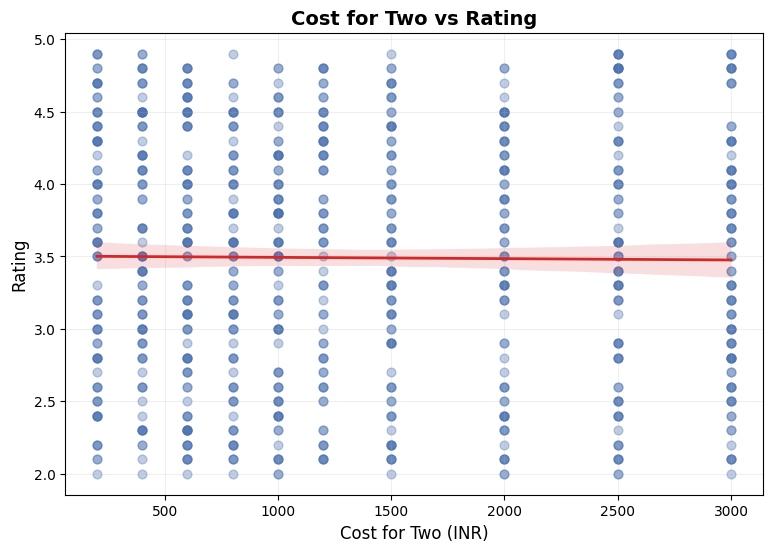

In [229]:
plt.figure(figsize=(9,6))

sns.regplot(
    data=df,
    x='cost_for_two',
    y='rate',
    scatter_kws={
        'alpha':0.35,
        'color':'#4C72B0',
        's':40
    },
    line_kws={
        'color':'#D62728',
        'linewidth':2
    }
)

plt.title("Cost for Two vs Rating", fontsize=14, fontweight='bold')
plt.xlabel("Cost for Two (INR)", fontsize=12)
plt.ylabel("Rating", fontsize=12)

plt.grid(alpha=0.2)
plt.show()

In [230]:
df_loc = df[df['location'].isin(['whitefield','koramangala'])]
df_loc['location'].value_counts()

location
koramangala    109
whitefield     102
Name: count, dtype: int64

C:\Users\lakshmi\AppData\Local\Temp\ipykernel_39320\1554135919.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


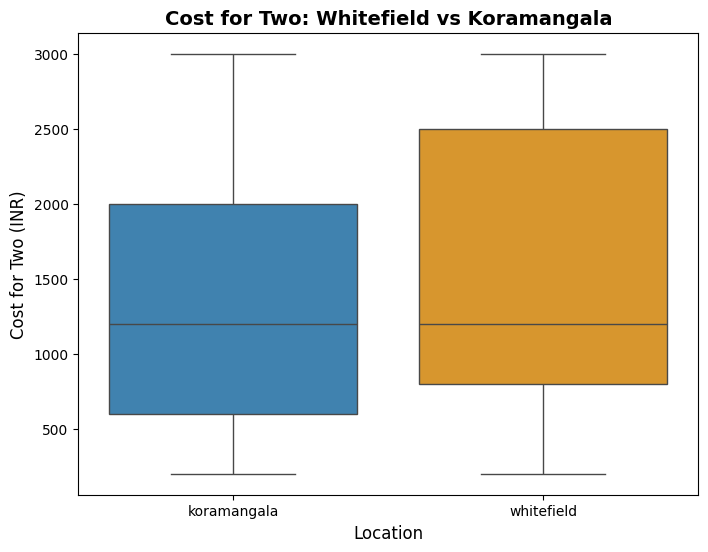

In [231]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df_loc,
    x='location',
    y='cost_for_two',
    palette=['#2E86C1','#F39C12']
)

plt.title("Cost for Two: Whitefield vs Koramangala", fontsize=14, fontweight='bold')
plt.xlabel("Location", fontsize=12)
plt.ylabel("Cost for Two (INR)", fontsize=12)

plt.show()

In [232]:
df_loc.groupby('location')['cost_for_two'].mean()

location
koramangala    1337.614679
whitefield     1459.803922
Name: cost_for_two, dtype: float64

In [233]:
df.groupby('online_order')['cost_for_two'].mean()

online_order
0    1389.861751
1    1269.756098
Name: cost_for_two, dtype: float64

C:\Users\lakshmi\AppData\Local\Temp\ipykernel_39320\907525561.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


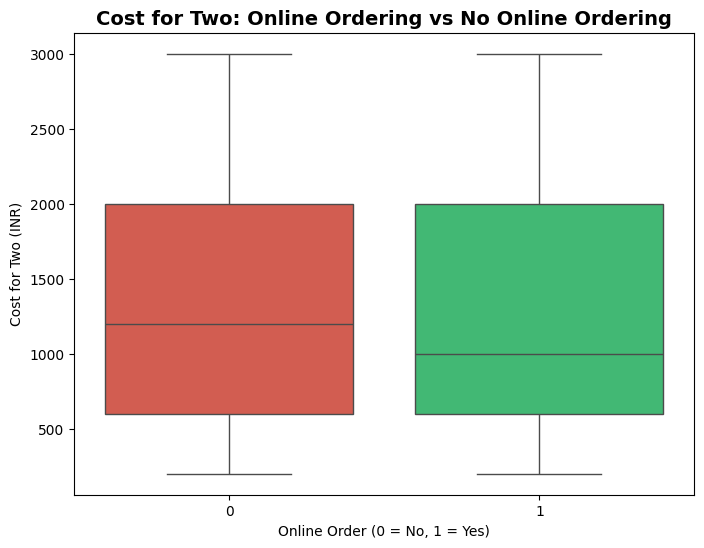

In [234]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x='online_order',
    y='cost_for_two',
    palette=['#E74C3C','#2ECC71']
)

plt.title("Cost for Two: Online Ordering vs No Online Ordering", fontsize=14, fontweight='bold')
plt.xlabel("Online Order (0 = No, 1 = Yes)")
plt.ylabel("Cost for Two (INR)")

plt.show()

In [235]:
df[['votes','rate']].corr()

,votes,rate
votes,1.000000,0.014005
rate,0.014005,1.000000


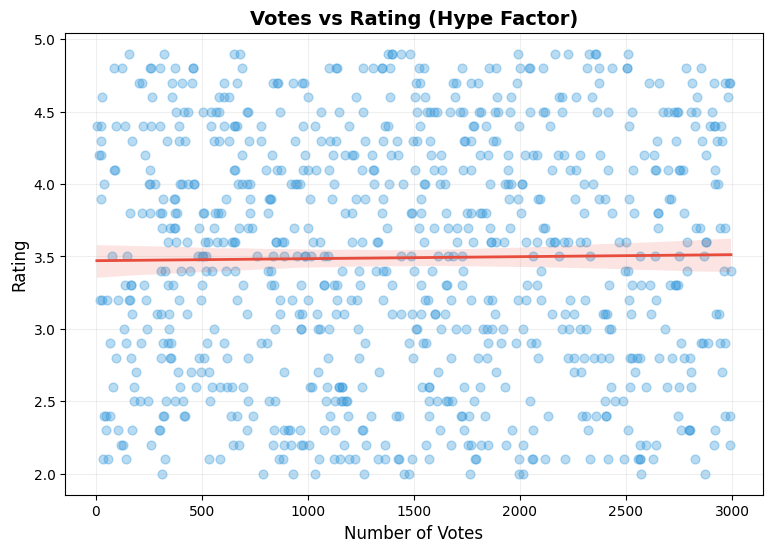

In [236]:
plt.figure(figsize=(9,6))

sns.regplot(
    data=df,
    x='votes',
    y='rate',
    scatter_kws={'alpha':0.35, 'color':'#3498DB', 's':40},
    line_kws={'color':'#E74C3C', 'linewidth':2}
)

plt.title("Votes vs Rating (Hype Factor)", fontsize=14, fontweight='bold')
plt.xlabel("Number of Votes", fontsize=12)
plt.ylabel("Rating", fontsize=12)
plt.grid(alpha=0.2)

plt.show()

In [237]:
df['multi_cuisine'] = (df['cuisines_count'] >= 3).astype(int)
df['multi_cuisine'].value_counts()

multi_cuisine
1    529
0    315
Name: count, dtype: int64

In [238]:
df.groupby('multi_cuisine')['rate'].mean()

multi_cuisine
0    3.470159
1    3.503403
Name: rate, dtype: float64

C:\Users\lakshmi\AppData\Local\Temp\ipykernel_39320\386657953.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


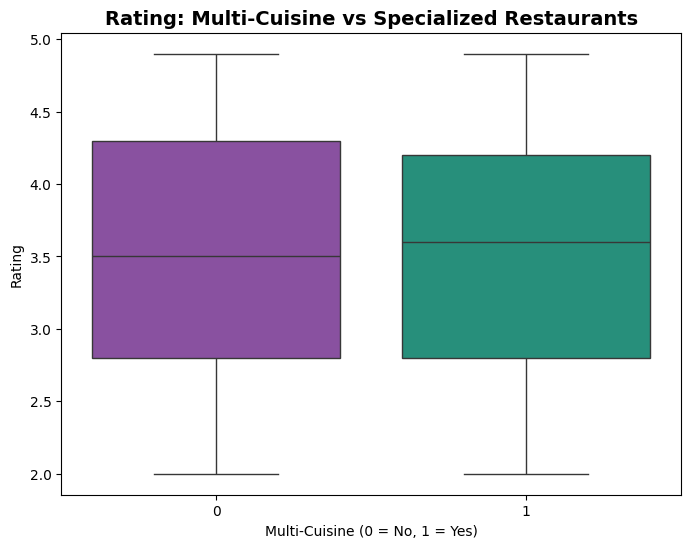

In [239]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x='multi_cuisine',
    y='rate',
    palette=['#8E44AD','#16A085']
)

plt.title("Rating: Multi-Cuisine vs Specialized Restaurants", fontsize=14, fontweight='bold')
plt.xlabel("Multi-Cuisine (0 = No, 1 = Yes)")
plt.ylabel("Rating")

plt.show()

In [240]:
df_high = df[df['high_rated'] == 1]
df_high['location'].value_counts()

location
indiranagar     49
jayanagar       42
hsr layout      41
jp nagar        39
marathahalli    38
koramangala     33
whitefield      28
mg road         25
Name: count, dtype: int64

In [241]:
high_count = df_high['location'].value_counts()
high_count

location
indiranagar     49
jayanagar       42
hsr layout      41
jp nagar        39
marathahalli    38
koramangala     33
whitefield      28
mg road         25
Name: count, dtype: int64

C:\Users\lakshmi\AppData\Local\Temp\ipykernel_39320\1707635354.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


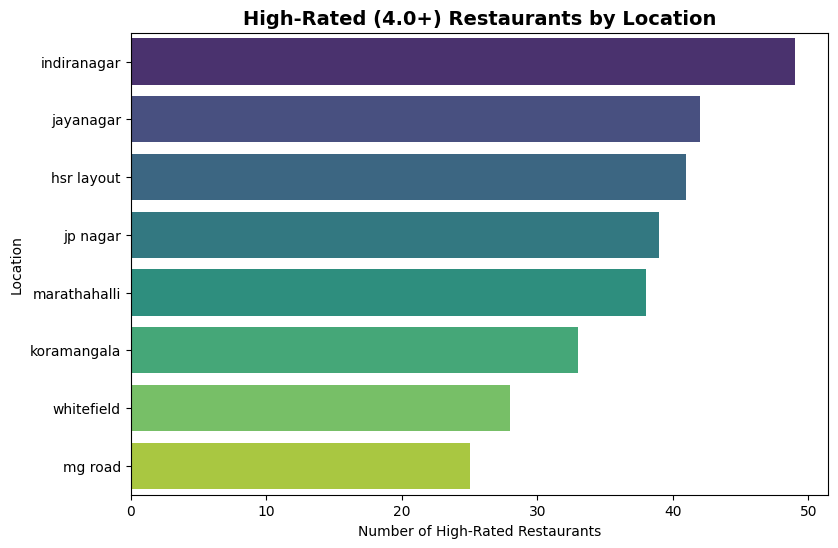

In [242]:
plt.figure(figsize=(9,6))

sns.barplot(
    x=high_count.values,
    y=high_count.index,
    palette='viridis'
)

plt.title("High-Rated (4.0+) Restaurants by Location",
          fontsize=14, fontweight='bold')
plt.xlabel("Number of High-Rated Restaurants")
plt.ylabel("Location")

plt.show()

In [243]:
df_ind = df[df['location'] == 'indiranagar']

In [244]:
df_ind['service_type'].value_counts()

service_type
pubs and bars         26
dine-out              25
cafes                 19
buffet                16
delivery              12
drinks & nightlife    12
Name: count, dtype: int64

C:\Users\lakshmi\AppData\Local\Temp\ipykernel_39320\1576063156.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


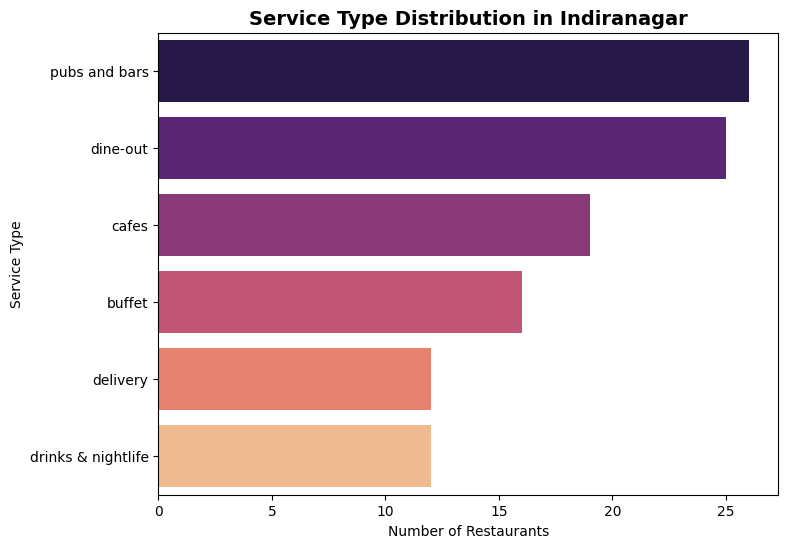

In [245]:
plt.figure(figsize=(8,6))

sns.barplot(
    x=df_ind['service_type'].value_counts().values,
    y=df_ind['service_type'].value_counts().index,
    palette='magma'
)

plt.title("Service Type Distribution in Indiranagar",
          fontsize=14, fontweight='bold')
plt.xlabel("Number of Restaurants")
plt.ylabel("Service Type")

plt.show()

In [246]:
df.groupby('book_table')['votes'].mean()


book_table
0    1432.785548
1    1456.180723
Name: votes, dtype: float64

C:\Users\lakshmi\AppData\Local\Temp\ipykernel_39320\3366062204.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


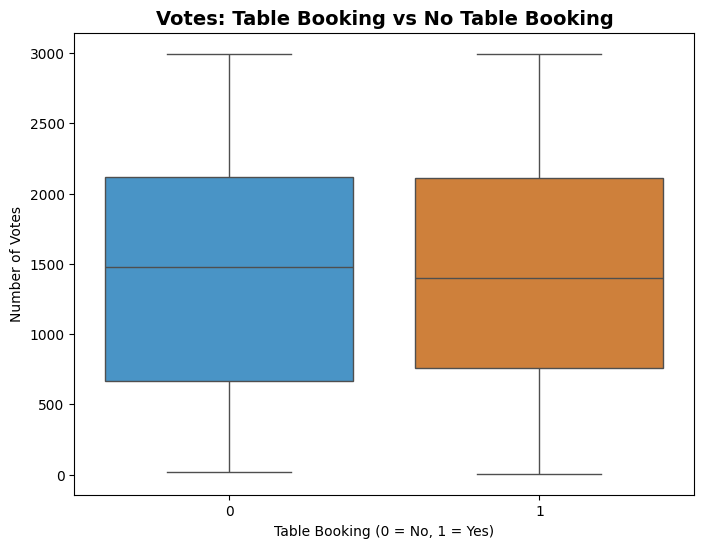

In [247]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x='book_table',
    y='votes',
    palette=['#3498DB','#E67E22']
)

plt.title("Votes: Table Booking vs No Table Booking",
          fontsize=14, fontweight='bold')
plt.xlabel("Table Booking (0 = No, 1 = Yes)")
plt.ylabel("Number of Votes")

plt.show()

In [248]:
top_chains = df['name'].value_counts().head(5).index
top_chains

Index(['Leon Grill', 'McDonald's', 'Nandhana Palace', 'Onesta', 'Pizza Hut'], dtype='str', name='name')

In [249]:
df_top = df[df['name'].isin(top_chains)]

C:\Users\lakshmi\AppData\Local\Temp\ipykernel_39320\1754125413.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


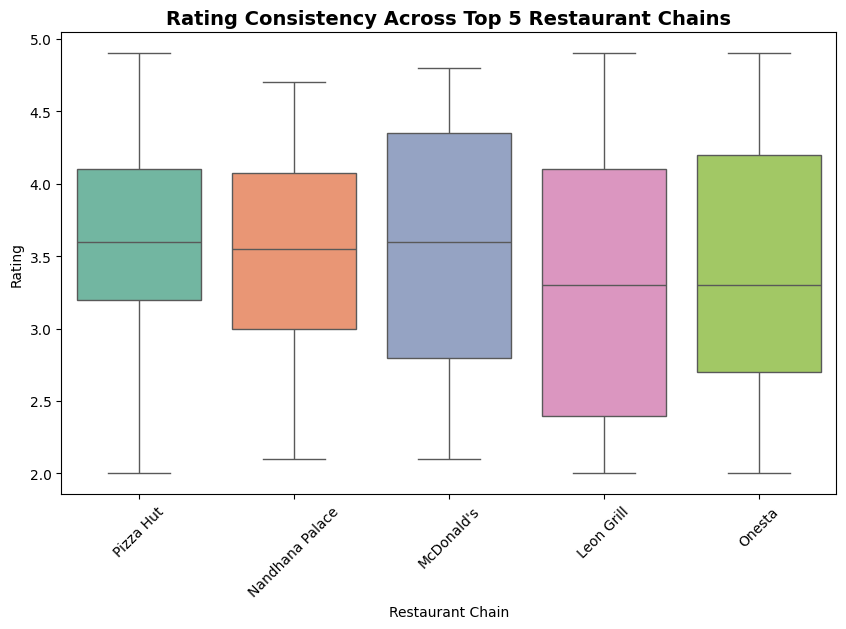

In [250]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_top,
    x='name',
    y='rate',
    palette='Set2'
)

plt.title("Rating Consistency Across Top 5 Restaurant Chains",
          fontsize=14, fontweight='bold')
plt.xlabel("Restaurant Chain")
plt.ylabel("Rating")
plt.xticks(rotation=45)

plt.show()

In [251]:
df['city'].unique()

<StringArray>
['bengaluru']
Length: 1, dtype: str

In [252]:
df.drop(columns=['city'], inplace=True)
df.shape

(844, 17)

In [253]:
df.drop(columns=['cost_per_person'], inplace=True)
df.shape

(844, 16)

In [254]:
df.drop(columns=['dish_liked'], inplace=True)
df.shape

(844, 15)

In [255]:
df.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes', 'location',
       'rest_type', 'cuisines', 'cost_for_two', 'cuisines_count',
       'service_type', 'high_rated', 'price_category', 'vote_category',
       'multi_cuisine'],
      dtype='str')

In [256]:
df.to_csv("round1_cleaned.csv", index=False)

C:\Users\lakshmi\AppData\Local\Temp\ipykernel_39320\2274737349.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


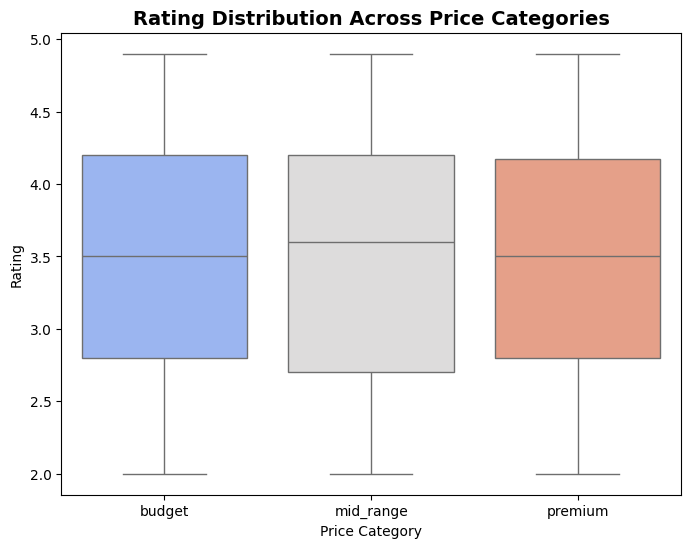

In [257]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x='price_category',
    y='rate',
    order=['budget','mid_range','premium'],
    palette='coolwarm'
)

plt.title("Rating Distribution Across Price Categories",
          fontsize=14, fontweight='bold')
plt.xlabel("Price Category")
plt.ylabel("Rating")

plt.show()